# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [149]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

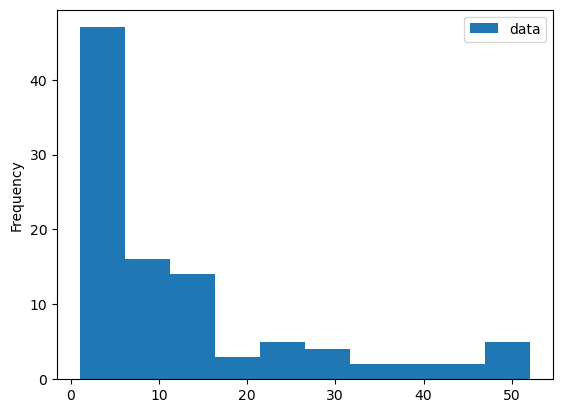

In [150]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

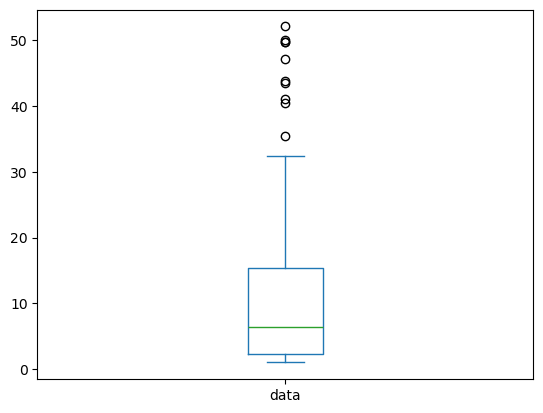

In [151]:
df.plot.box()

HISTOGRAM VS BOXPLOT PROS AND CONS:
- Hist Pros: Good visual representation, easily readable, shows each body length category and the number of occurences (frequency)
- Hist Cons: Individual data points are hidden 
- Boxplot Pros: Great for visualizing percentiles, variations, and outliers
- Boxplot Cons: Individual data points are hidden and so is the distribution shape, designed for numerical data

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [152]:
# NCHS Death Rates and Life Expectancy dataset
nchs = pd.read_csv('https://data.cdc.gov/api/views/w9j2-ggv5/rows.csv?accessType=DOWNLOAD', sep=',')
print(nchs.head(5))

   Year       Race         Sex  Average Life Expectancy (Years)  \
0  1900  All Races  Both Sexes                             47.3   
1  1901  All Races  Both Sexes                             49.1   
2  1902  All Races  Both Sexes                             51.5   
3  1903  All Races  Both Sexes                             50.5   
4  1904  All Races  Both Sexes                             47.6   

   Age-adjusted Death Rate  
0                   2518.0  
1                   2473.1  
2                   2301.3  
3                   2379.0  
4                   2502.5  


In [153]:
# ANALYSIS:

# Mean, median, and mode of each column
num = nchs.select_dtypes(include=[np.number])

nchs_mean = num.mean()
print("Mean:\n", nchs_mean)

nchs_median = num.median()
print("Median:\n", nchs_median)

nchs_mode = num.mode().iloc[0]  # first mode if multiple modes exist
print("Mode:\n", nchs_mode)

Mean:
 Year                               1959.000000
Average Life Expectancy (Years)      64.500188
Age-adjusted Death Rate            1593.061625
dtype: float64
Median:
 Year                               1959.0
Average Life Expectancy (Years)      66.8
Age-adjusted Death Rate            1513.7
dtype: float64
Mode:
 Year                               1900.0
Average Life Expectancy (Years)      66.8
Age-adjusted Death Rate             623.5
Name: 0, dtype: float64


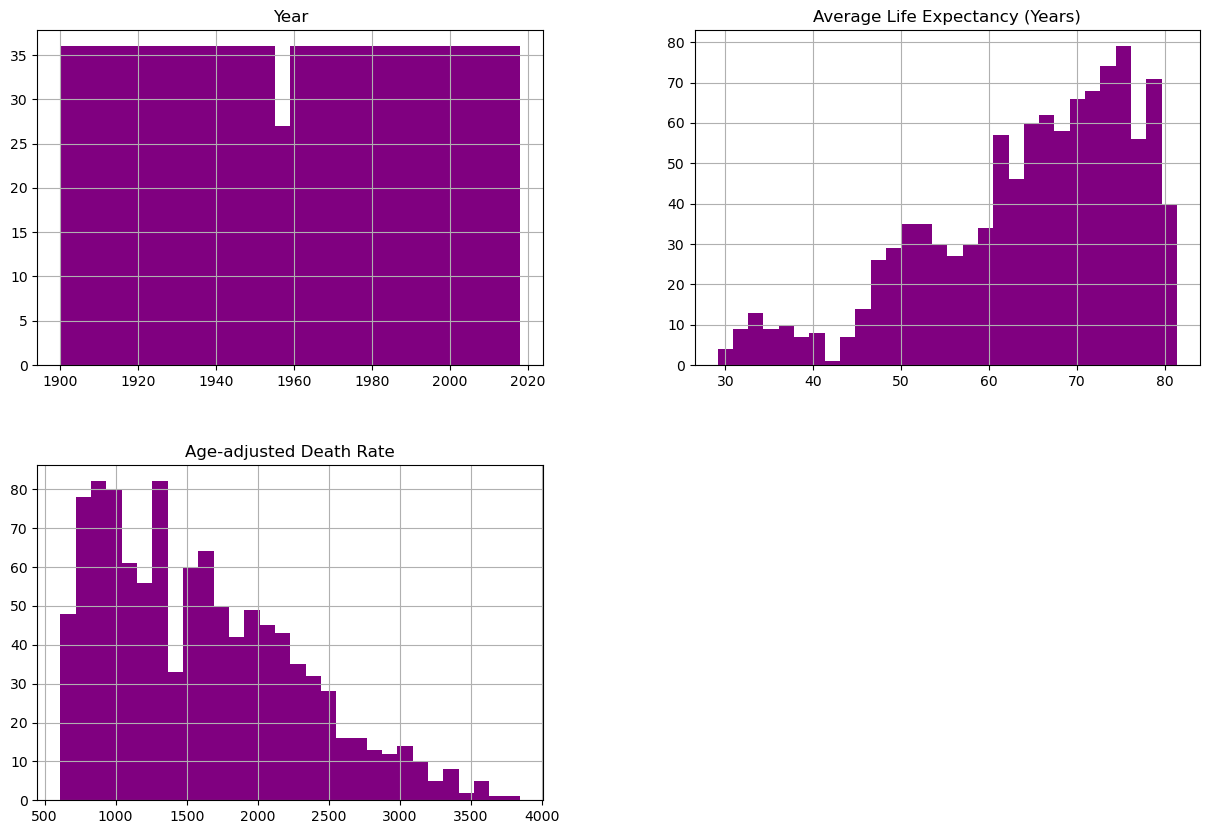

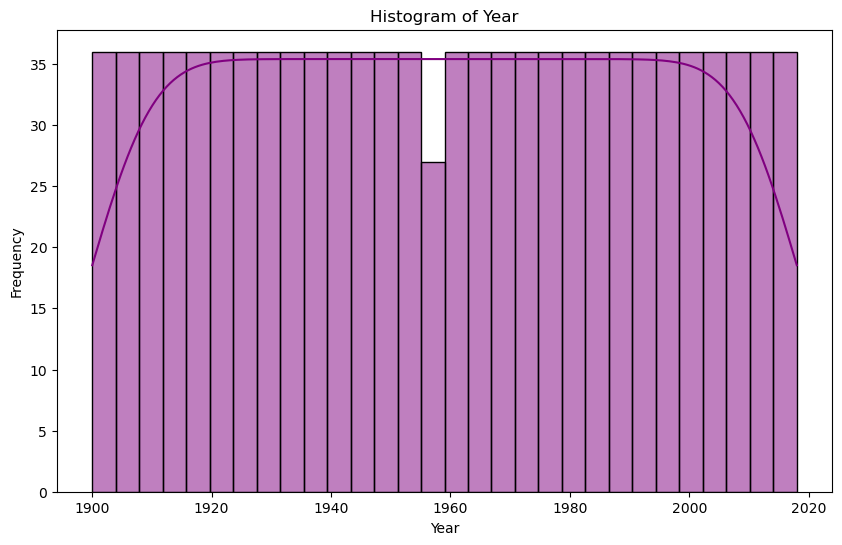

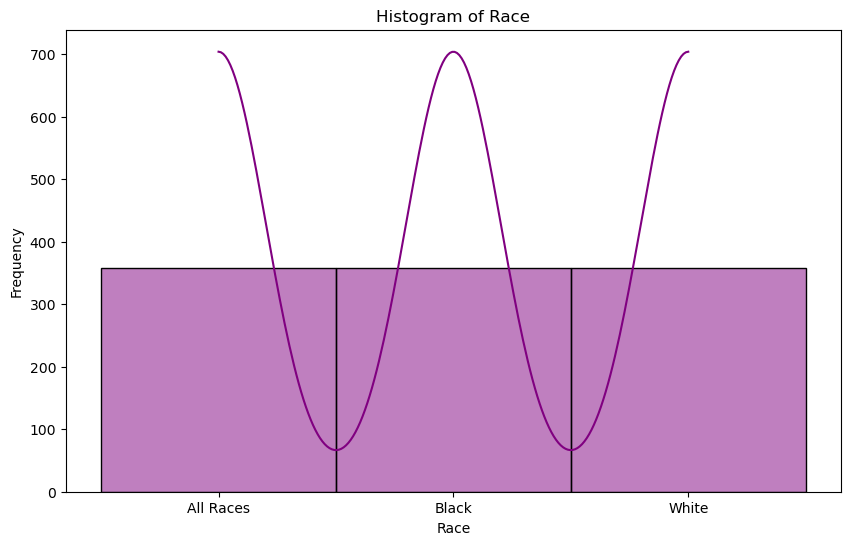

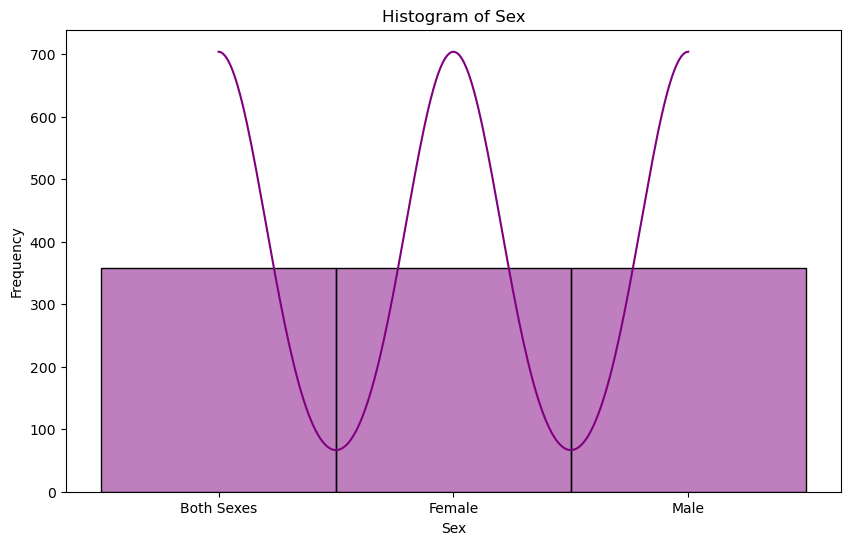

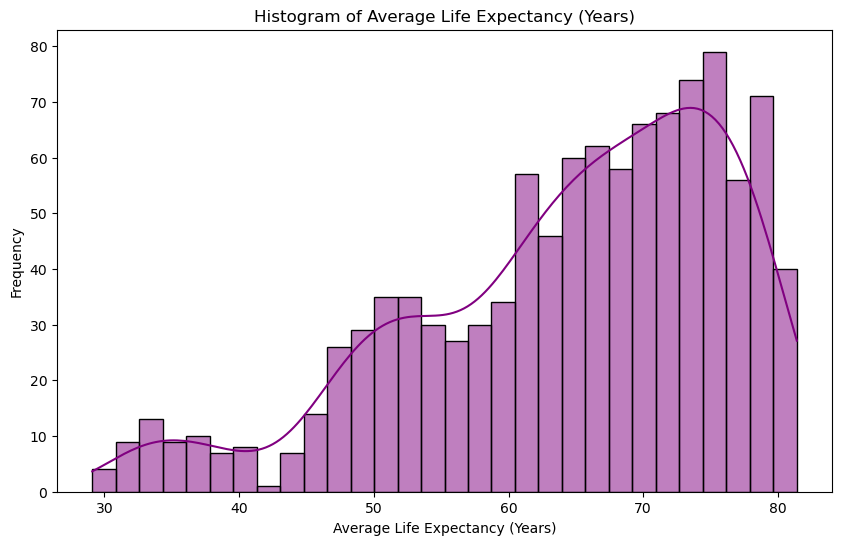

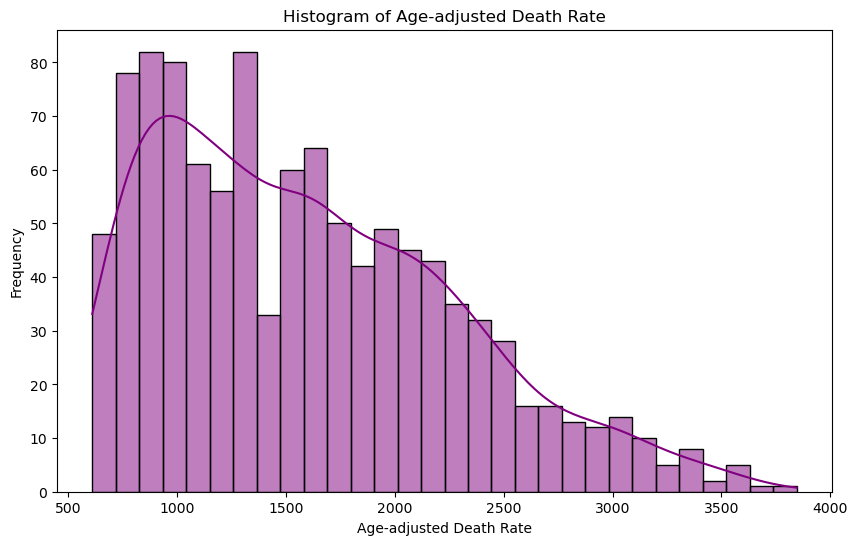

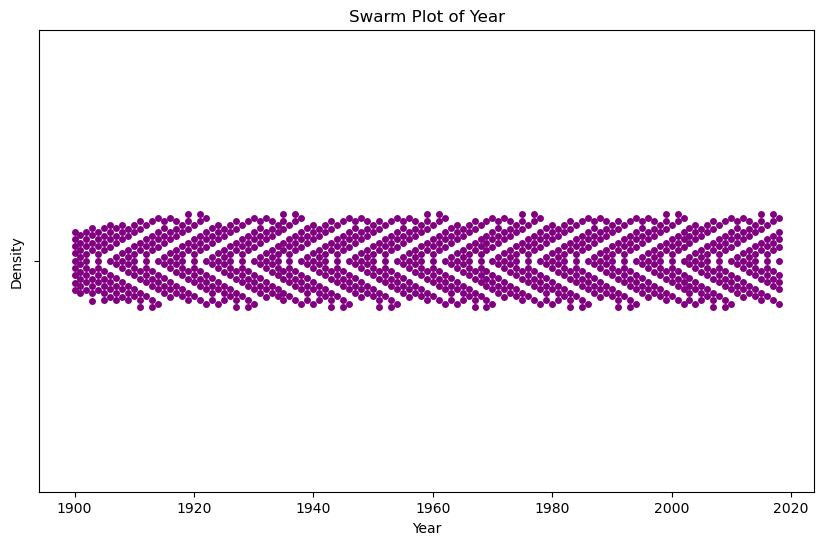

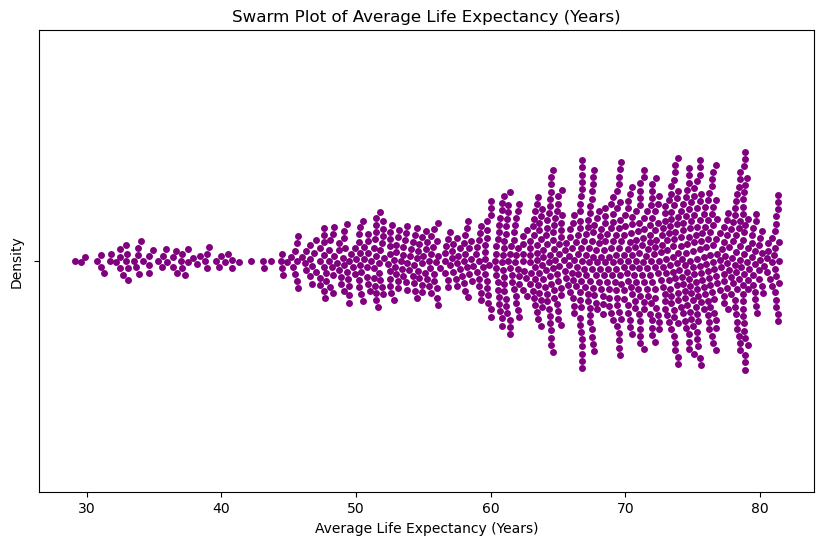

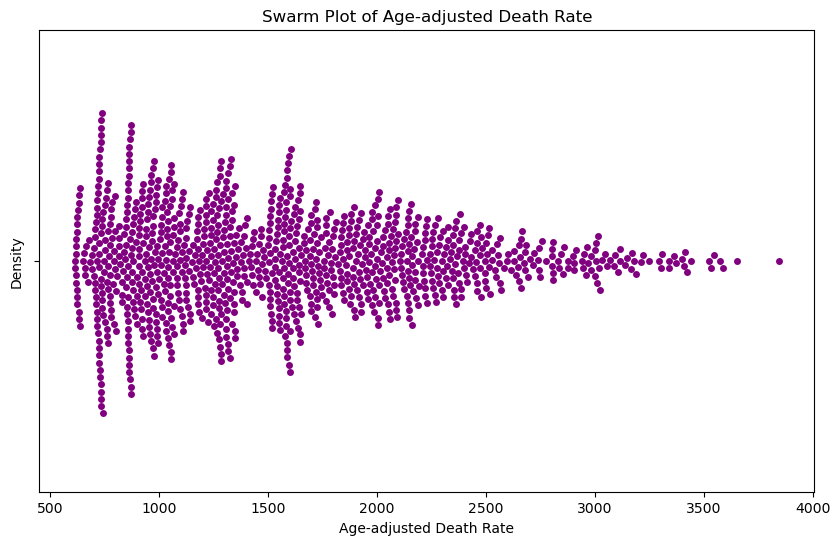

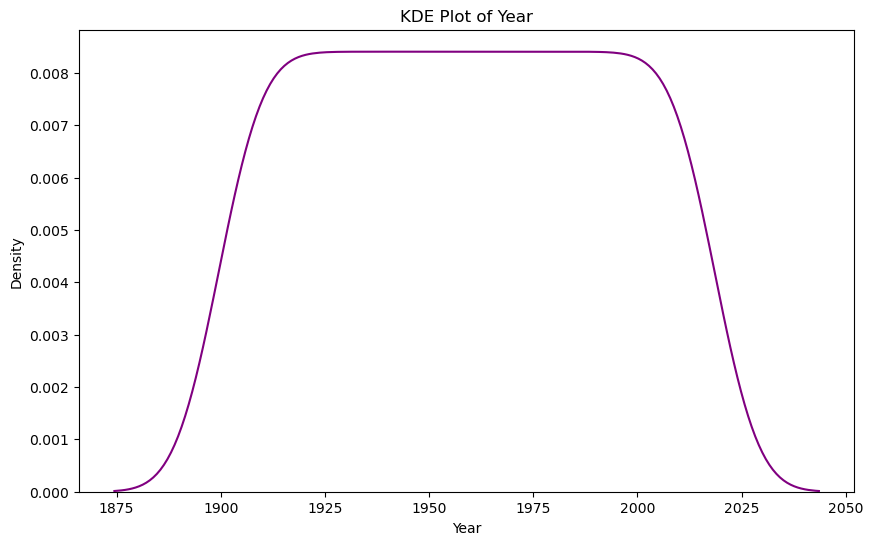

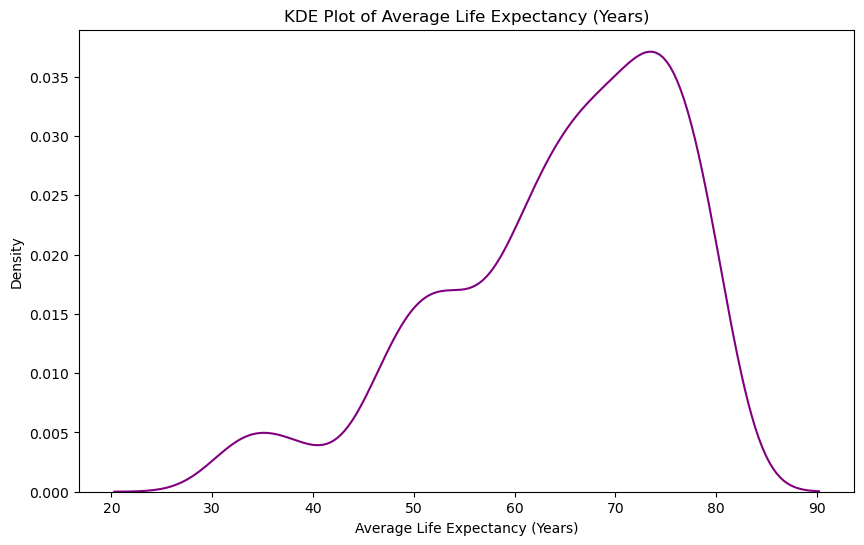

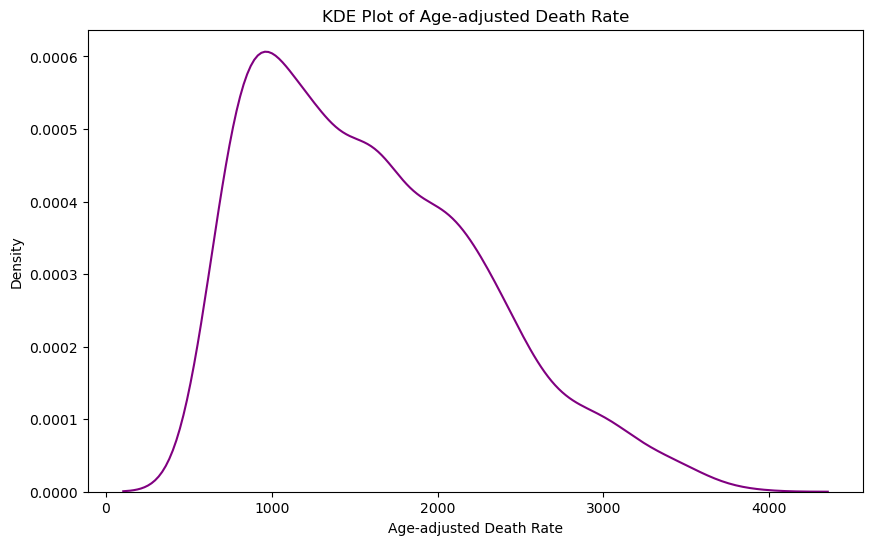

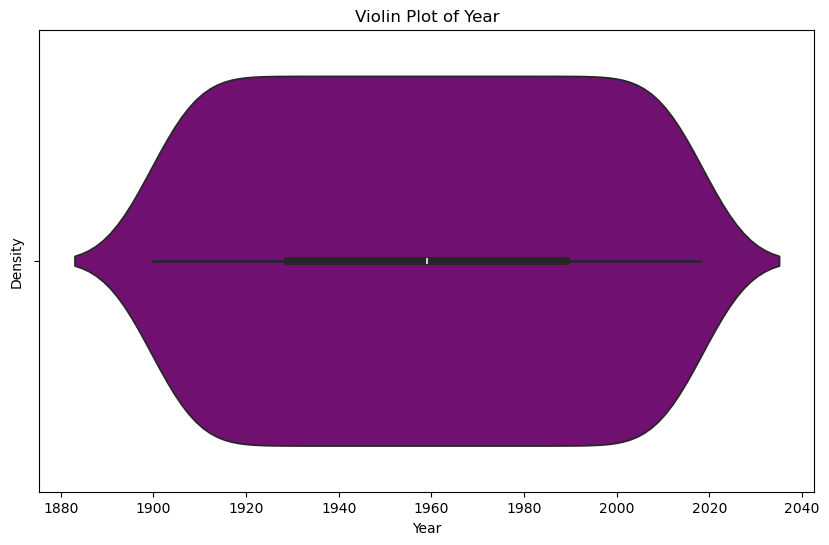

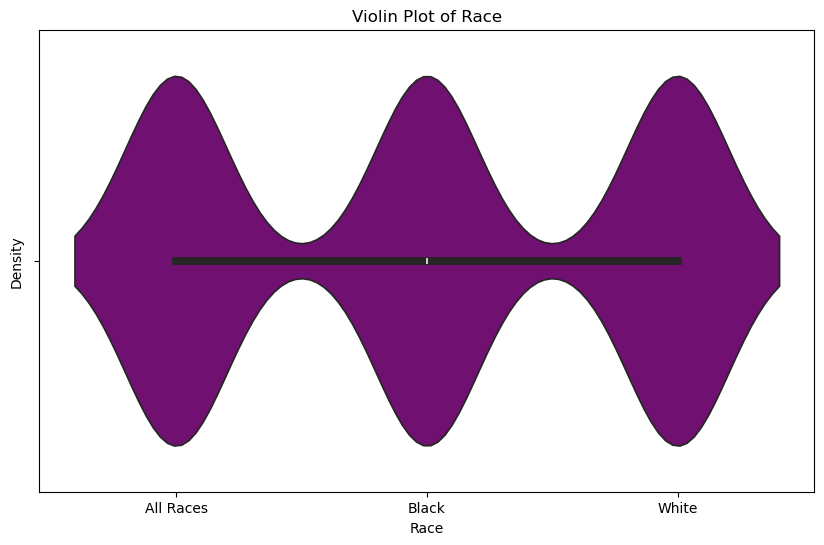

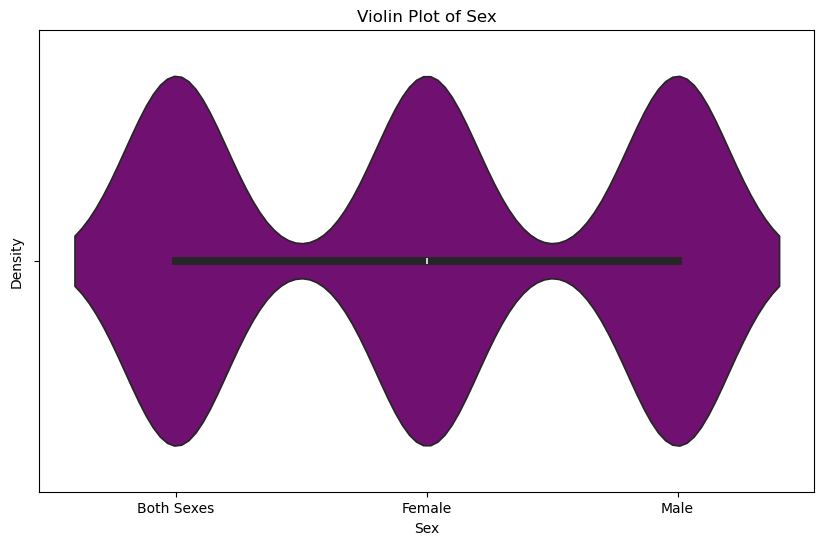

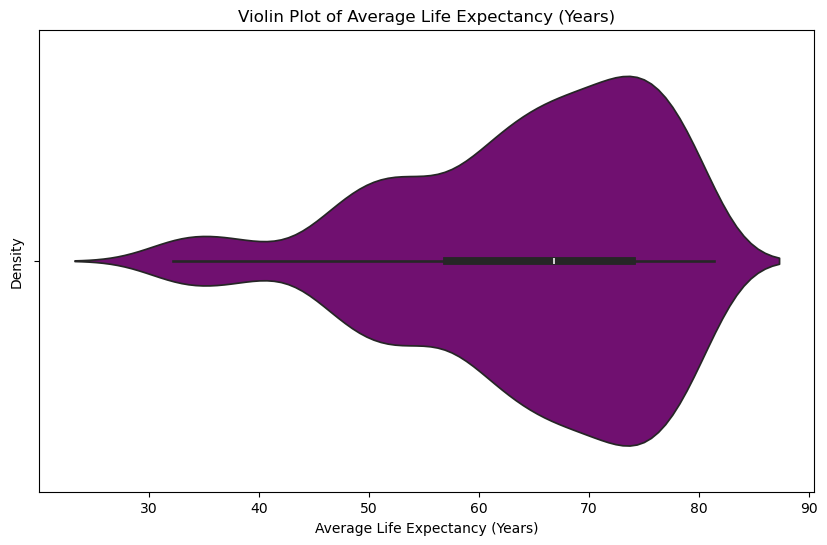

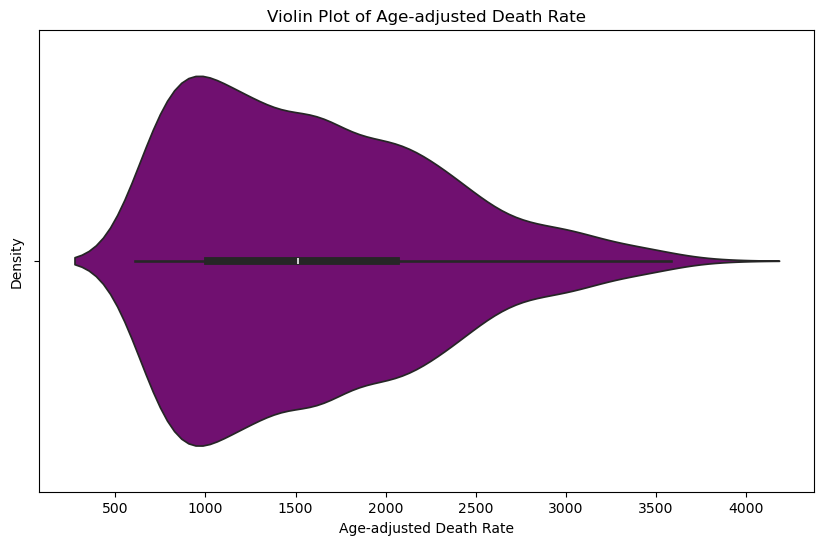

In [154]:
# MORE ANALYSIS:

# Histogram of each feature
nchs.hist(bins=30, figsize=(15, 10), color='purple')

# Histogram variations:
# Histogram plot of each feature (with KDE)
for column in nchs.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(nchs[column], bins=30, kde=True, color='purple')
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.show()

# Swarm plot of each feature (numeric columns only)
for column in nchs.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 6))
    sns.swarmplot(x=nchs[column], color='purple')
    plt.title(f'Swarm Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

# kdeplot of each feature (numeric columns only)
for column in nchs.select_dtypes(include=['float64', 'int64']).columns:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(nchs[column], color='purple')
    plt.title(f'KDE Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()

# Violin plot of each feature
for column in nchs.columns:
    plt.figure(figsize=(10, 6))
    sns.violinplot(x=nchs[column], color='purple')
    plt.title(f'Violin Plot of {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.show()


Categorical features: ['Race', 'Sex']


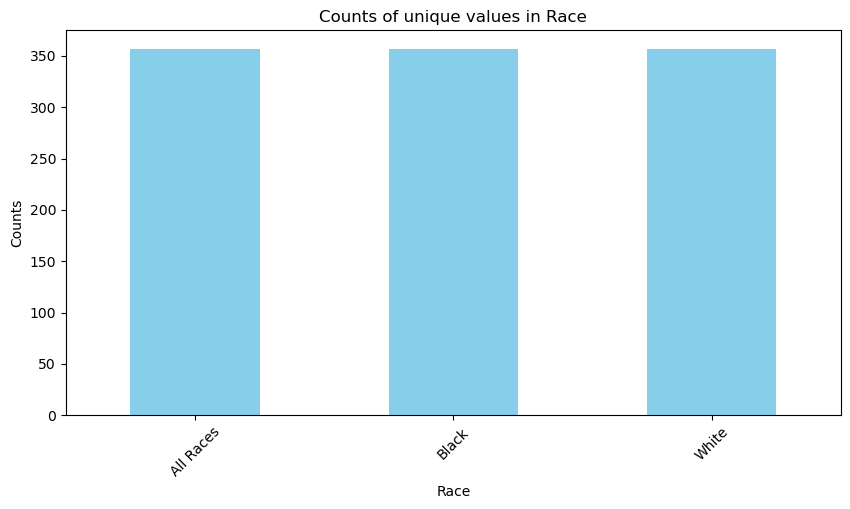

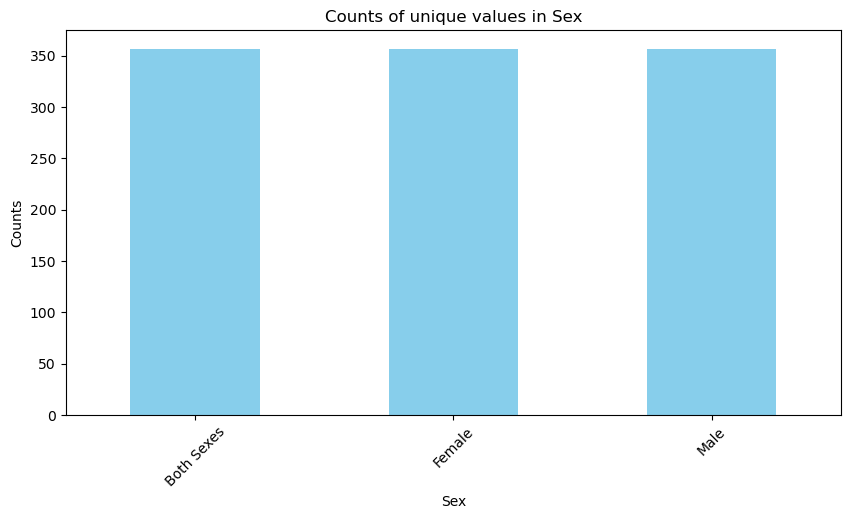

In [155]:
# MORE ANALYSIS:

# Bar plot to indicate counts of each categorical variable
categorical_features = nchs.select_dtypes(exclude=['number']).columns.tolist()    # To get list of categorical features
print(f'\nCategorical features: {categorical_features}')

for column in categorical_features:
    plt.figure(figsize=(10, 5))
    nchs[column].value_counts().plot(kind='bar', color='skyblue')
    plt.title(f'Counts of unique values in {column}')
    plt.xlabel(column)
    plt.ylabel('Counts')
    plt.xticks(rotation=45)
    plt.show()

CONCLUSIONS:
- For the most part, I'd say the data are what I expect and highly useable. I think the categorical variables (race an sex), after so preprocessing, like encoding as numbers, can give more insight on the data.
- The overall shape of the data varies per feature--normal for Year, skewed-right for Age-Adjusted Death Rate , and skewed-left for Average Life Expectancy (Years).
- There are a few oultiers present. 
- The minimum and maximum values presented in each histogram (categorical features) are: 1900 to 2018 for Year, 29.1 to 81.4 for Average Life Expectancy (Years), and 611.3 to 3845.7 for Age-adjusted Death Rate. 
- Bin size is very important and so is finding the right bin size that can accurately reppresent the data. The fewer bins, the less variation (typically). Meanwhile, the more bins, the more variation. 

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

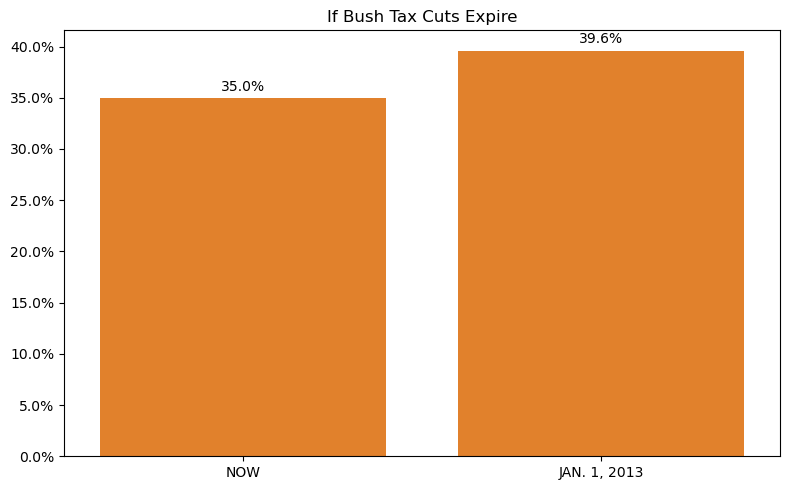

In [156]:
# STORYTELLING WITH DATA GRAPH:

# If Bush Tax Cuts Expire bar chart
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ["NOW", "JAN. 1, 2013"]
values = [0.35, 0.396]   # proportions (0-1)

plt.figure(figsize=(8,5))
ax = sns.barplot(x=metrics, y=values, color="#ff7f0e", orient='v')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))  # format y ticks as percent

# Annotate each bar above with percent text
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{100*height:.1f}%', 
                (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10, xytext=(0,3), textcoords='offset points')

plt.title('If Bush Tax Cuts Expire')
plt.tight_layout()
plt.show()